For installing the Libraries that we need:

In [1]:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn

For loading the our dataset:

In [2]:
import pandas as pd
df = pd.read_csv("/content/sample_data/train.csv")
print(df.head())
print(df.shape)
print(df.columns)

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

Now it is time to preprocessing:

In [3]:

import pandas as pd

df = pd.read_csv("/content/sample_data/train.csv")

print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [4]:
from sklearn.preprocessing import LabelEncoder

df.drop("Loan_ID", axis=1, inplace=True)
label_cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'

]
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
df["Dependents"] = df["Dependents"].replace("3+", 3)
df["Dependents"] = pd.to_numeric(df["Dependents"])

df.fillna(df.median(numeric_only=True), inplace=True)
print(df.isnull().sum())


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


We are going for spliting our model to Train/Test part

In [5]:
from sklearn.model_selection import train_test_split

x = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

It is time to create Missing Values for our dataset:


In [6]:
import numpy as np
def inject_missing_values(data, percentage):
    corrupted = data.copy()
    total_values = corrupted.size
    n_missing = int(total_values * percentage)
    rows = np.random.randint(
        0,
        corrupted.shape[0],
        n_missing
    )
    cols = np.random.randint(
        0,
        corrupted.shape[1],
        n_missing
    )
    corrupted.values[rows, cols] = np.nan

    return corrupted

For Example we can see:

In [7]:
X_missing_10 = inject_missing_values(
    X_train,
    0.10
)

print(X_missing_10.isnull().sum())


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


Let's start Imputation for our dataset:

In [8]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_missing_10 = pd.DataFrame(
    imputer.fit_transform(X_missing_10),
    columns=X_train.columns
)

STEP 6 : Let's talk about Label Noise Function

In [9]:
def inject_label_noise(y, percentage):
    y_noisy = y.copy()
    n_flip = int(len(y)* percentage)
    flip_idx = np.random.choice(
        len(y),
        n_flip,
        replace=False
    )
    y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]
    return y_noisy


For example:

In [10]:
y_noise_20 = inject_label_noise(
    y_train,
    0.20
)

Let's talk about our Models:


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
models = {
    "Logistic Regression":
        LogisticRegression(max_iter=2000),
    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),
    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",

        )

}

Let's implement our Evaluation Function

In [12]:
from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
def evaluate_model(model,
                   X_train,
                   y_train,
                   X_test,
                   y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "accuracy":
            accuracy_score(y_test, pred),
        "Precision":
            precision_score(y_test, pred),
        "Recall":
            recall_score(y_test, pred),
        "F1":
            f1_score(y_test, pred)
    }

Now we are trying to Run Experiments:

In [13]:
results = []
corruption_levels = [
    0,
    0.05,
    0.10,
    0.20,
    0.30
]
for level in corruption_levels:
    X_corrupt = inject_missing_values(
        X_train,
        level
    )
    imputer = SimpleImputer(
        strategy="median"
    )

    X_corrupt = pd.DataFrame(
        imputer.fit_transform(X_corrupt),
        columns=X_train.columns
    )
    for name, model in models.items():
        metrics = evaluate_model(
            model,
            X_corrupt,
            y_train,
            X_test,
            y_test
        )
        metrics["Model"] = name
        metrics["Missing"] = level
        results.append(metrics)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Let's save the Results:

In [14]:
import os
import pandas as pd
os.makedirs("results", exist_ok=True)
results_df = pd.DataFrame(results)
results_df.to_csv(
    "results/missing_results.csv",
    index=False
)
print(results_df.head())

   accuracy  Precision    Recall        F1                Model  Missing
0  0.861789   0.840000  0.988235  0.908108  Logistic Regression     0.00
1  0.845528   0.851064  0.941176  0.893855        Random Forest     0.00
2  0.813008   0.844444  0.894118  0.868571              XGBoost     0.00
3  0.861789   0.840000  0.988235  0.908108  Logistic Regression     0.05
4  0.845528   0.851064  0.941176  0.893855        Random Forest     0.05


For a better understanding,we will try to drow a graphs

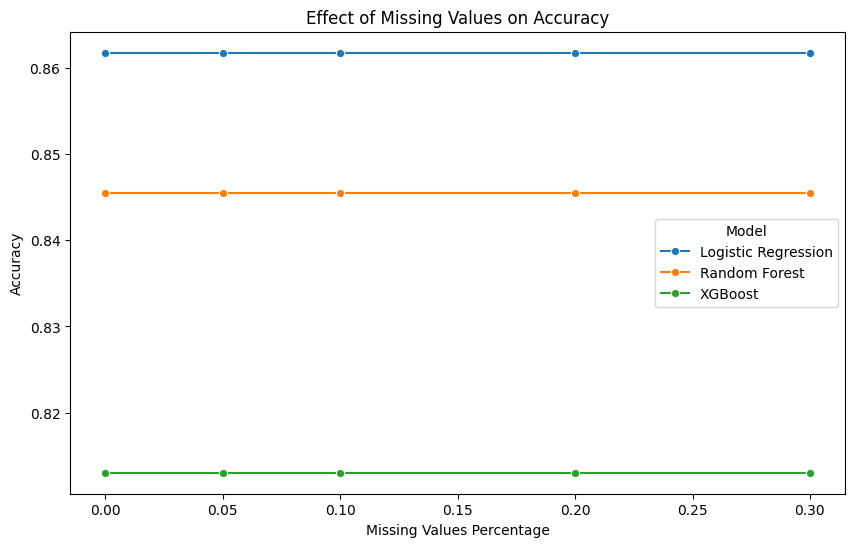

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(

    data=results_df,
    x="Missing",
    y="accuracy",
    hue="Model",
    marker="o"
)
plt.title("Effect of Missing Values on Accuracy")
plt.xlabel("Missing Values Percentage")
plt.ylabel("Accuracy")

plt.show()

We Repeat for Label Noise:

In [16]:
import numpy as np
def inject_label_noise(y, percentage):
  y_noisy = y.copy()
  n_flip = int(len(y)* percentage)
  flip_idx = np.random.choice(
      len(y),
      n_flip,
      replace=False

  )
  y_noisy.iloc[flip_idx] = 1 - y_noisy.iloc[flip_idx]
  return y_noisy

y_noise_10 = inject_label_noise(y_train, 0.10)
print(y_train.head())
print(y_noise_10.head())

154    1
239    1
448    0
471    0
273    1
Name: Loan_Status, dtype: int64
154    1
239    1
448    1
471    0
273    1
Name: Loan_Status, dtype: int64


Instead of:

inject_missing_values()

In [17]:
import pandas as pd
Label_noise_results_df = pd.DataFrame(results)

Label_noise_results_df.to_csv(
    "Label_noise_results.csv",
    index=False
)
print(Label_noise_results_df.head())

   accuracy  Precision    Recall        F1                Model  Missing
0  0.861789   0.840000  0.988235  0.908108  Logistic Regression     0.00
1  0.845528   0.851064  0.941176  0.893855        Random Forest     0.00
2  0.813008   0.844444  0.894118  0.868571              XGBoost     0.00
3  0.861789   0.840000  0.988235  0.908108  Logistic Regression     0.05
4  0.845528   0.851064  0.941176  0.893855        Random Forest     0.05
